In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


1. Data Gathering & Data Reading

In [5]:
df = pd.read_csv(r"C:\Users\Asus\E-commerce customer segmentation & prediction\data\data.csv",encoding="cp1252")
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


2. Data Preprocessing

In [6]:
df.shape

(541909, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
df.isnull().mean() * 100

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

In [15]:
df.dropna(inplace = True, how = 'any')

In [16]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64

In [17]:
df['InvoiceDate'].iloc[0] #Timestamp('2010-12-01 08:26:00')

Timestamp('2010-12-01 08:26:00')

In [18]:
df.describe(include = 'all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
count,406829,406829,406829,406829.000000,406829,406829.000000,406829.000000,406829,406829.000000
unique,22190,3684,3896,NaN,NaN,NaN,NaN,37,NaN
top,576339,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom,NaN
freq,542,2077,2070,NaN,NaN,NaN,NaN,361878,NaN
mean,NaN,NaN,NaN,12.061303,2011-07-10 16:30:57.879207424,3.460471,15287.690570,NaN,20.401854
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000,NaN,-168469.600000
25%,NaN,NaN,NaN,2.000000,2011-04-06 15:02:00,1.250000,13953.000000,NaN,4.200000
50%,NaN,NaN,NaN,5.000000,2011-07-31 11:48:00,1.950000,15152.000000,NaN,11.100000
75%,NaN,NaN,NaN,12.000000,2011-10-20 13:06:00,3.750000,16791.000000,NaN,19.500000
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN,168469.600000


In [19]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')

3. Key Data Insights

In [20]:
# 1. Country-wise Customer Distribution
df["Country"].value_counts().head()

Country
United Kingdom    361878
Germany             9495
France              8491
EIRE                7485
Spain               2533
Name: count, dtype: int64

In [21]:
# High-Valued Products
df.groupby("Description").agg({"UnitPrice":"max"}).sort_values("UnitPrice", ascending = False).head()

,UnitPrice
Description,
Manual,38970.00
POSTAGE,8142.75
Discount,1867.86
DOTCOM POSTAGE,1599.26
CRUK Commission,1100.44


In [22]:
#High Revenue Generating Products
df['TotalRevenue'] = df['Quantity'] * df['UnitPrice']
top_products = df.groupby('Description')['TotalRevenue'].sum().sort_values(ascending=False).head(10)
top_products

Description
REGENCY CAKESTAND 3 TIER              132870.40
WHITE HANGING HEART T-LIGHT HOLDER     93823.85
JUMBO BAG RED RETROSPOT                83236.76
PARTY BUNTING                          67687.53
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56499.22
RABBIT NIGHT LIGHT                     51137.80
CHILLI LIGHTS                          45936.81
PAPER CHAIN KIT 50'S CHRISTMAS         41500.48
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: TotalRevenue, dtype: float64

In [23]:
# Total Quantity Sold
df.groupby("Description").agg({"Quantity":"sum"}).head()

,Quantity
Description,
4 PURPLE FLOCK DINNER CANDLES,140
50'S CHRISTMAS GIFT BAG LARGE,1883
DOLLY GIRL BEAKER,2391
I LOVE LONDON MINI BACKPACK,360
I LOVE LONDON MINI RUCKSACK,1


In [24]:
# Unique Invoices
df["InvoiceNo"].nunique()

22190

In [25]:
# First Invoice Date
df['InvoiceDate'].iloc[0]

Timestamp('2010-12-01 08:26:00')

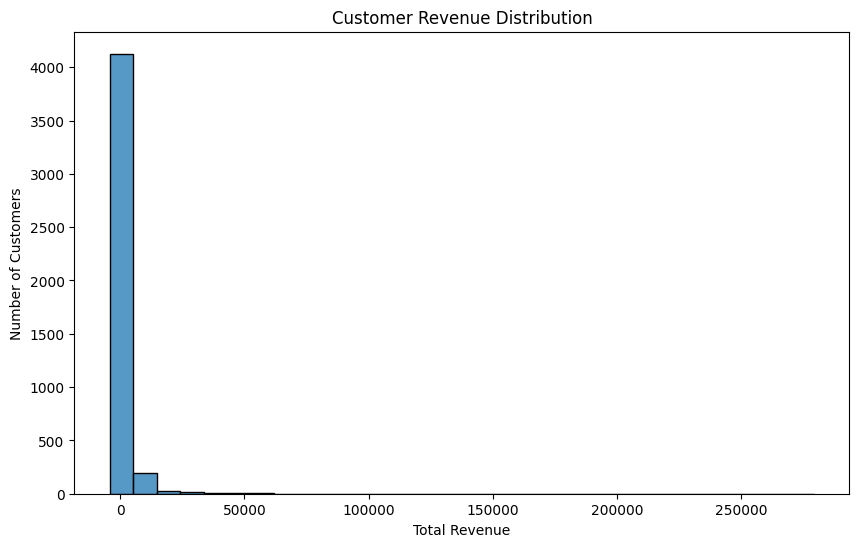

In [26]:
#total revenue per customer
customer_revenue = df.groupby('CustomerID')['TotalRevenue'].sum()

#purchase frequency per customer
purchase_frequency = df.groupby('CustomerID')['InvoiceNo'].count()

#average order value per customer
average_order_value = customer_revenue / purchase_frequency

# purchase patterns over time
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('InvoiceMonth')['TotalRevenue'].sum()


# Visualize customer revenue distribution
plt.figure(figsize=(10, 6))
sns.histplot(customer_revenue, bins=30)
plt.title('Customer Revenue Distribution')
plt.xlabel('Total Revenue')
plt.ylabel('Number of Customers')
plt.show()

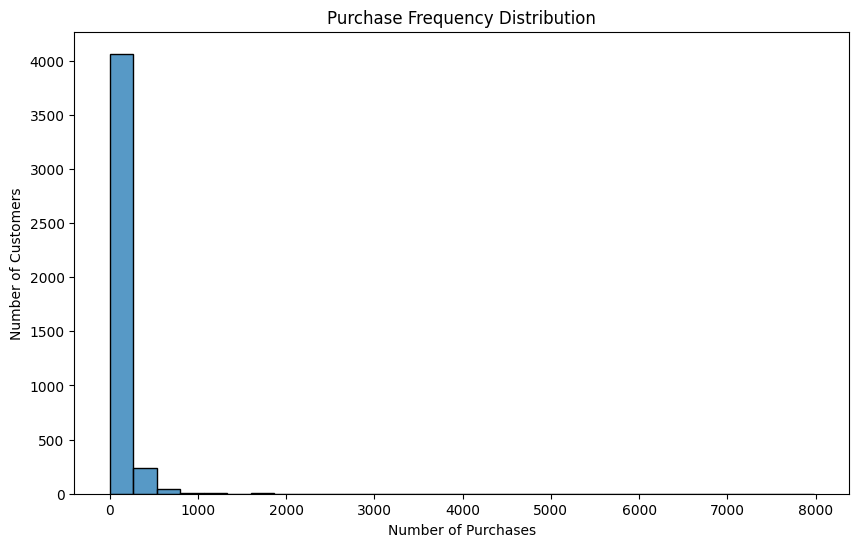

In [27]:
# Visualize purchase frequency distribution
plt.figure(figsize=(10, 6))
sns.histplot(purchase_frequency, bins=30)
plt.title('Purchase Frequency Distribution')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')
plt.show()

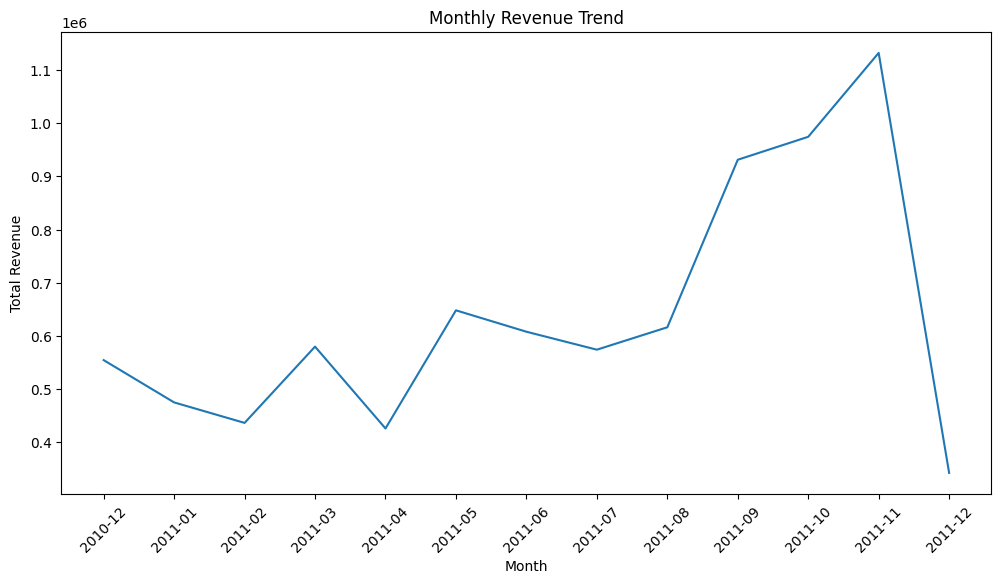

In [28]:
# Visualize monthly revenue trends
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

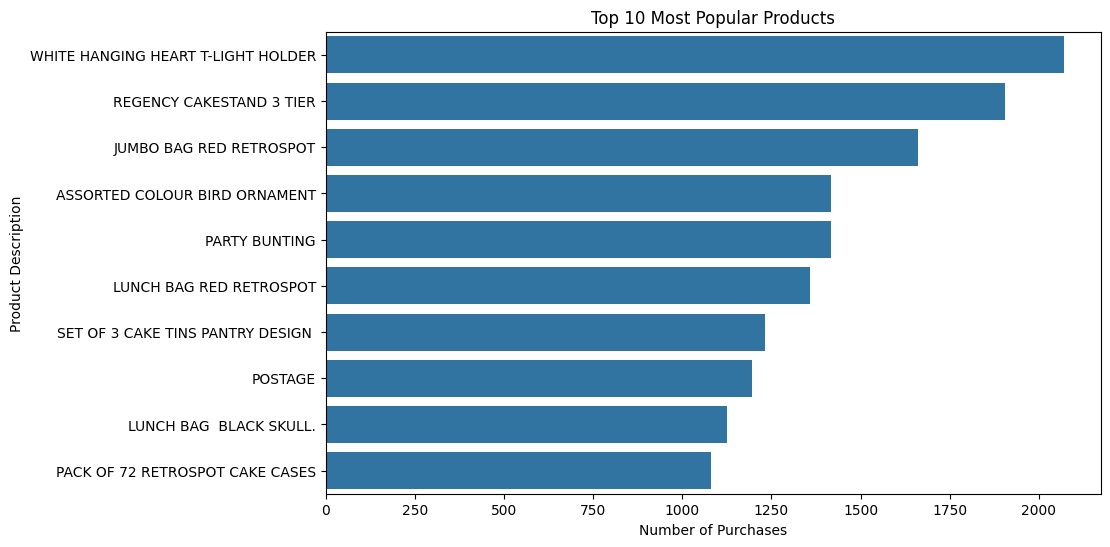

In [29]:
# Analyze product popularity
product_popularity = df['Description'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=product_popularity.values, y=product_popularity.index)
plt.title('Top 10 Most Popular Products')
plt.xlabel('Number of Purchases')
plt.ylabel('Product Description')
plt.show()

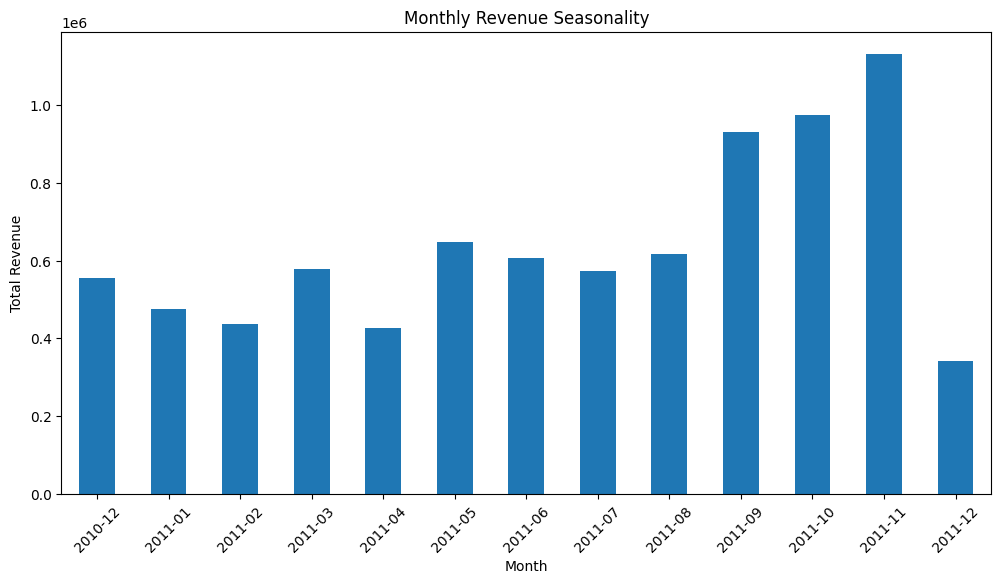

In [30]:
# Analyze sales seasonality using monthly revenue data
plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='bar')
plt.title('Monthly Revenue Seasonality')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

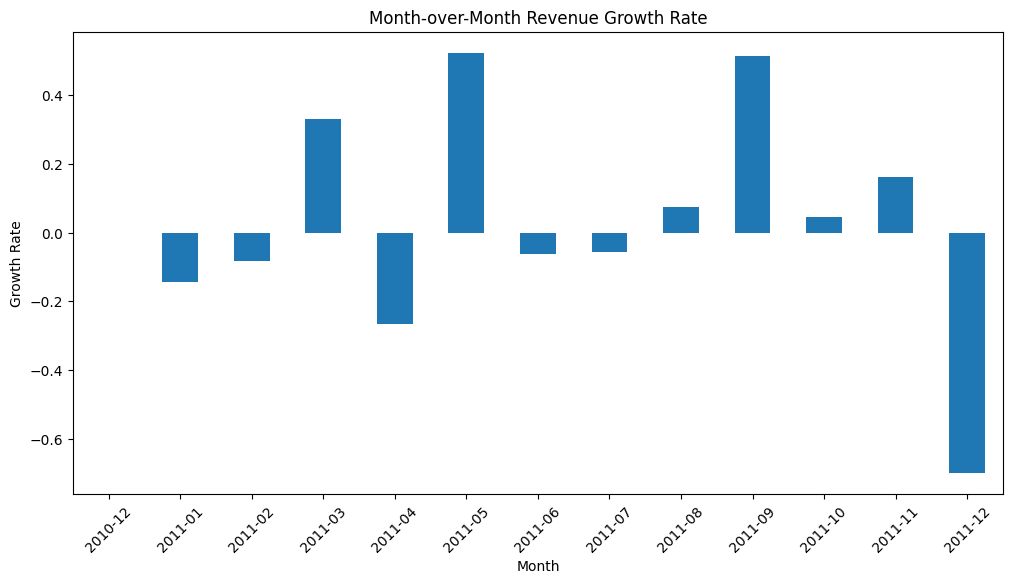

In [31]:
# Calculate and visualize the month-over-month revenue growth rate
monthly_revenue_growth = monthly_revenue.pct_change()
plt.figure(figsize=(12, 6))
monthly_revenue_growth.plot(kind='bar')
plt.title('Month-over-Month Revenue Growth Rate')
plt.xlabel('Month')
plt.ylabel('Growth Rate')
plt.xticks(rotation=45)
plt.show()

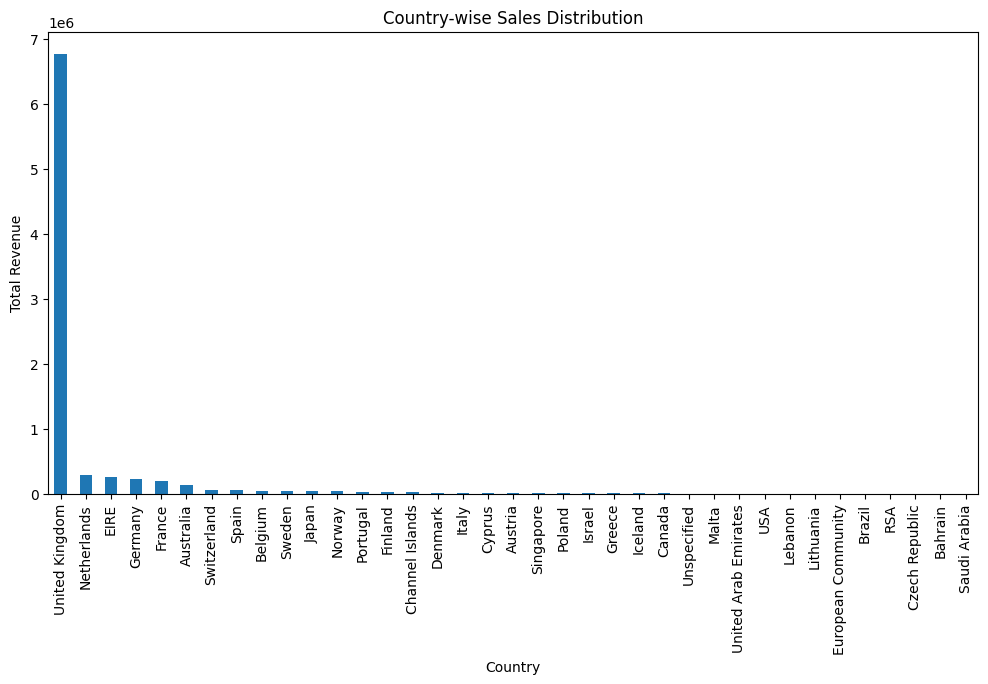

In [32]:
# Country-wise Sales Distribution
country_sales = df.groupby('Country')['TotalRevenue'].sum().sort_values(ascending=False)

# Visualize country-wise sales distribution
plt.figure(figsize=(12, 6))
country_sales.plot(kind='bar')
plt.title('Country-wise Sales Distribution')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.xticks(rotation=90)
plt.show()

4.Feature Engineering

In [33]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [34]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,TotalRevenue,InvoiceMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34,2010-12


5. RFM Analysis

In [36]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [37]:
rfm = df.groupby('CustomerID').agg({'InvoiceDate': lambda InvoiceDate: (reference_date - InvoiceDate.max()).days,
                                     'InvoiceNo': 'count',
                                     'TotalPrice': 'sum'})
rfm.head()

,InvoiceDate,InvoiceNo,TotalPrice
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [38]:
rfm.rename(columns = {'InvoiceDate':'Recency','InvoiceNo':'Frequency','TotalPrice':'Value'})

,Recency,Frequency,Value
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40
...,...,...,...
18280.0,278,10,180.60
18281.0,181,7,80.82
18282.0,8,13,176.60


In [39]:
rfm.rename(columns = {'InvoiceDate':'Recency','InvoiceNo':'Frequency','TotalPrice':'Value'}, inplace=True)

In [40]:
quantiles = rfm.quantile(q=[0.25,0.50,0.75])

def RScore(x, p, d):
  if p == 'Recency':

    if x <= d[p][0.25]:
      return 4
    elif x <= d[p][0.50]:
      return 3
    elif x <= d[p][0.75]:
      return 2
    else:
      return 1
  else:
    if x <= d[p][0.25]:
      return 1
    elif x <= d[p][0.50]:
      return 2
    elif x <= d[p][0.75]:
      return 3
    else:
      return 4

rfm['R'] = rfm['Recency'].apply(RScore, args=('Recency',quantiles))
rfm['F'] = rfm['Frequency'].apply(RScore, args=('Frequency',quantiles))
rfm['M'] = rfm['Value'].apply(RScore, args=('Value',quantiles))
rfm.head()

,Recency,Frequency,Value,R,F,M
CustomerID,,,,,,
12346.0,326,2,0.00,1,1,1
12347.0,2,182,4310.00,4,4,4
12348.0,75,31,1797.24,2,2,4
12349.0,19,73,1757.55,3,3,4
12350.0,310,17,334.40,1,1,2


In [41]:
rfm['RFM_Segment'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['RFM_Score'] = rfm[['R','F','M']].sum(axis=1)
rfm.head()

,Recency,Frequency,Value,R,F,M,RFM_Segment,RFM_Score
CustomerID,,,,,,,,
12346.0,326,2,0.00,1,1,1,111,3
12347.0,2,182,4310.00,4,4,4,444,12
12348.0,75,31,1797.24,2,2,4,224,8
12349.0,19,73,1757.55,3,3,4,334,10
12350.0,310,17,334.40,1,1,2,112,4


In [42]:
rfm['RFM_Score'].describe()

count    4372.000000
mean        7.501601
std         2.828144
min         3.000000
25%         5.000000
50%         7.000000
75%        10.000000
max        12.000000
Name: RFM_Score, dtype: float64

In [43]:
segment_labels = ['Low-Value', 'Mid-Value', 'High-Value']

In [44]:
def assign_segment(score):
  if score < 5:
    return 'Low Value'
  elif score <9:
    return 'Mid Value'
  else:
    return 'High Value'

rfm['RFM_Segment_Label'] = rfm['RFM_Score'].apply(assign_segment)
rfm.head()

,Recency,Frequency,Value,R,F,M,RFM_Segment,RFM_Score,RFM_Segment_Label
CustomerID,,,,,,,,,
12346.0,326,2,0.00,1,1,1,111,3,Low Value
12347.0,2,182,4310.00,4,4,4,444,12,High Value
12348.0,75,31,1797.24,2,2,4,224,8,Mid Value
12349.0,19,73,1757.55,3,3,4,334,10,High Value
12350.0,310,17,334.40,1,1,2,112,4,Low Value


In [45]:
segment_count = rfm['RFM_Segment_Label'].value_counts().reset_index()
segment_count.columns = ['RFM_Segment', 'Count']
segment_count = segment_count.sort_values('RFM_Segment')

In [46]:
import plotly.express as px

In [47]:
fig = px.bar(segment_count,
             x='RFM_Segment',
             y='Count',
             title='Count of Customers by RFM Segment',
             labels = {'RFM_Segment':'RFM Segment','Count':'Count of Customers'},
             color = 'RFM_Segment',
             color_discrete_sequence = px.colors.qualitative.Pastel,
             text='Count')
fig.show()

In [48]:
rfm['RFM_Customer_Segments'] = ''

rfm.loc[(rfm['RFM_Score'] >= 9), 'RFM_Customer_Segments'] = 'LoyalCustomers'  # High value
rfm.loc[(rfm['RFM_Score'] >= 6) & (rfm['RFM_Score'] < 9), 'RFM_Customer_Segments'] = 'Potential Loyalists'  # Mid value
rfm.loc[(rfm['RFM_Score'] >= 5) & (rfm['RFM_Score'] < 6), 'RFM_Customer_Segments'] = 'At Risk Customers'  # Mid value
rfm.loc[(rfm['RFM_Score'] >= 4) & (rfm['RFM_Score'] < 5), 'RFM_Customer_Segments'] = "Can't Lose Them"  # Low value
rfm.loc[(rfm['RFM_Score'] >= 3) & (rfm['RFM_Score'] < 4), 'RFM_Customer_Segments'] = 'Lost Customers'  # Low value

segment_count = rfm['RFM_Customer_Segments'].value_counts().sort_index()
segment_count

RFM_Customer_Segments
At Risk Customers       517
Can't Lose Them         391
Lost Customers          392
LoyalCustomers         1690
Potential Loyalists    1382
Name: count, dtype: int64

In [49]:
segment_product_count = rfm.groupby(['RFM_Segment_Label', 'RFM_Customer_Segments']).size().reset_index(name='Count')

segment_product_count = segment_product_count.sort_values('Count', ascending=False)

In [50]:
fig_treemap_segment = px.treemap(segment_product_count,
                                path=['RFM_Segment_Label', 'RFM_Customer_Segments'],
                                 values = 'Count',
                                 color = 'RFM_Segment_Label',
                                 color_discrete_sequence = px.colors.qualitative.Pastel,
                                 title = 'Segment Treemap')
fig_treemap_segment.update_traces(texttemplate='%{label}Count: %{value}', textinfo='label+text')
fig_treemap_segment.show()

6. Clustering Analysis

In [51]:
# Select only the numerical columns for scaling
rfm_values = rfm[['Recency', 'Frequency', 'Value']]

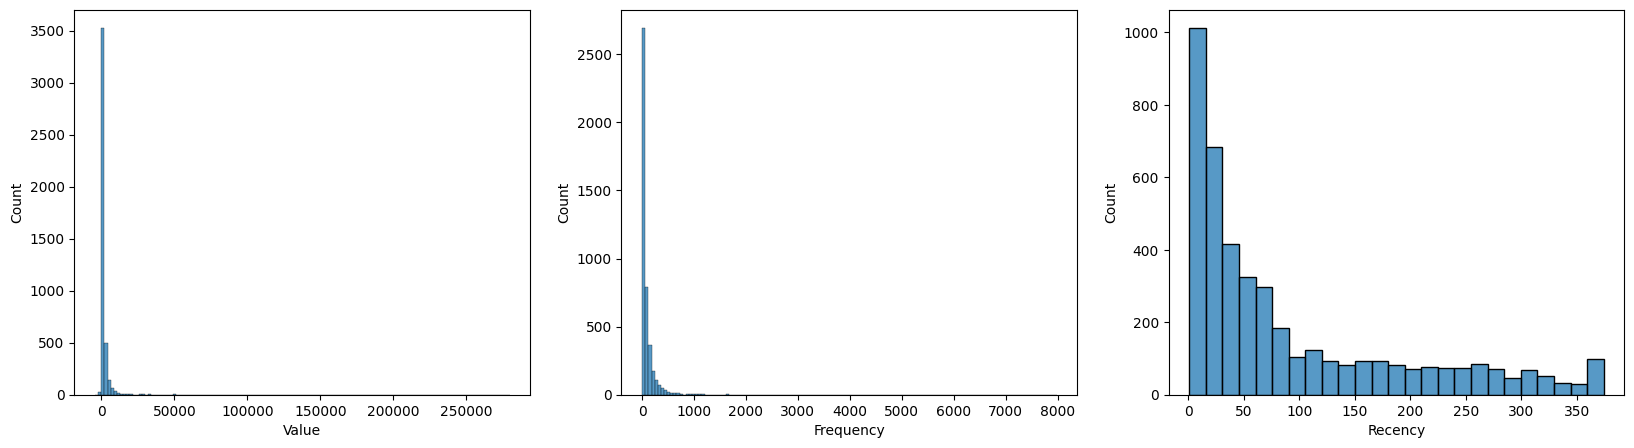

In [52]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
sns.histplot(rfm['Value'])
plt.subplot(1, 3, 2)
sns.histplot(rfm['Frequency'])
plt.subplot(1, 3, 3)
sns.histplot(rfm['Recency'])
plt.show(block=True)

In [53]:
from sklearn.preprocessing import MinMaxScaler

In [54]:
mms = MinMaxScaler().fit_transform(rfm_values)
rfm_cluster_scaled = pd.DataFrame(mms, columns=['Recency', 'Frequency', 'Value'], index=rfm.index)
rfm_cluster_scaled.head()

,Recency,Frequency,Value
CustomerID,,,
12346.0,0.871314,0.000125,0.015109
12347.0,0.002681,0.022676,0.030297
12348.0,0.198391,0.003758,0.021442
12349.0,0.048257,0.009020,0.021303
12350.0,0.828418,0.002005,0.016288


In [55]:
rfm_cluster_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4372.0,0.244094,0.270149,0.0,0.042895,0.131367,0.380697,1.0
Frequency,4372.0,0.011533,0.029124,0.0,0.002005,0.005137,0.012653,1.0
Value,4372.0,0.021799,0.028964,0.0,0.016143,0.017393,0.020789,1.0


In [56]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

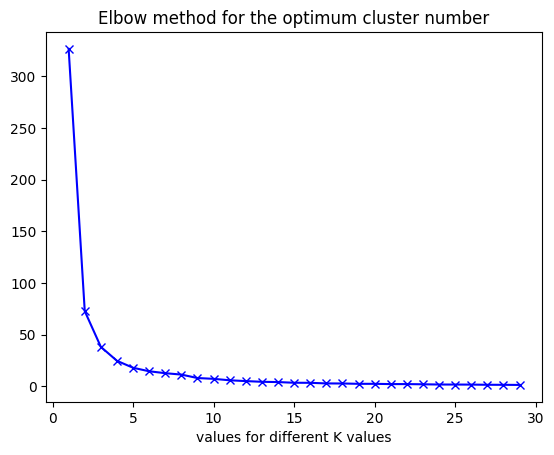

In [57]:
kmeans = KMeans()
ssd = []
K = range(1, 30)
for k in K:
    kmeans = KMeans(n_clusters=k).fit(rfm_cluster_scaled)
    ssd.append(kmeans.inertia_)

plt.plot(K, ssd, 'bx-')
plt.xlabel('values for different K values')
plt.title('Elbow method for the optimum cluster number')
plt.show(block=True)

In [58]:
silhouette_score_list = []
for i in range(2, 10):
    kmeans.fit(rfm_cluster_scaled)
    silhouette_score_list.append(silhouette_score(rfm_cluster_scaled, kmeans.labels_))
    print(silhouette_score_list)

[0.45223970317137596]
[0.45223970317137596, 0.4589503399599188]
[0.45223970317137596, 0.4589503399599188, 0.43127803045011137]
[0.45223970317137596, 0.4589503399599188, 0.43127803045011137, 0.4150850762606431]
[0.45223970317137596, 0.4589503399599188, 0.43127803045011137, 0.4150850762606431, 0.42331028972114515]
[0.45223970317137596, 0.4589503399599188, 0.43127803045011137, 0.4150850762606431, 0.42331028972114515, 0.4467560761631375]
[0.45223970317137596, 0.4589503399599188, 0.43127803045011137, 0.4150850762606431, 0.42331028972114515, 0.4467560761631375, 0.4275301143767047]
[0.45223970317137596, 0.4589503399599188, 0.43127803045011137, 0.4150850762606431, 0.42331028972114515, 0.4467560761631375, 0.4275301143767047, 0.43613250277508236]


In [59]:
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, max_iter=300)
kmeans.fit(rfm_cluster_scaled)
pred = kmeans.predict(rfm_cluster_scaled)

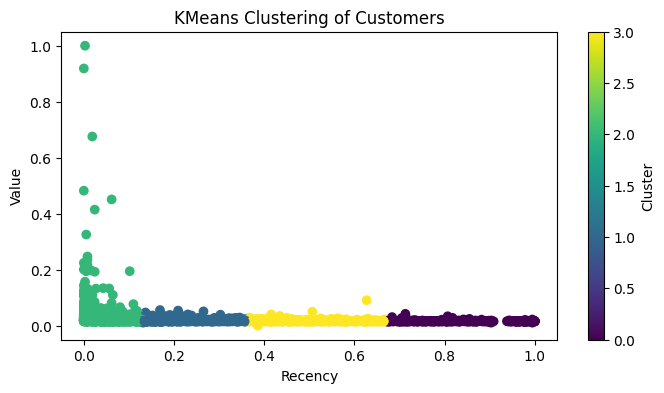

In [60]:
plt.figure(figsize=(8,4))
plt.scatter(rfm_cluster_scaled['Recency'], rfm_cluster_scaled['Value'], c=pred, cmap='viridis')
plt.xlabel('Recency')
plt.ylabel('Value')
plt.title('KMeans Clustering of Customers')
plt.colorbar(label='Cluster')
plt.show()

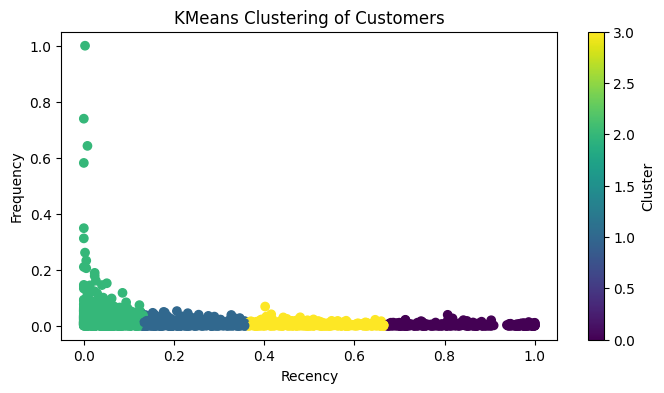

In [61]:
plt.figure(figsize=(8,4))
plt.scatter(rfm_cluster_scaled['Recency'], rfm_cluster_scaled['Frequency'], c=pred, cmap='viridis')
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.title('KMeans Clustering of Customers')
plt.colorbar(label='Cluster')
plt.show()

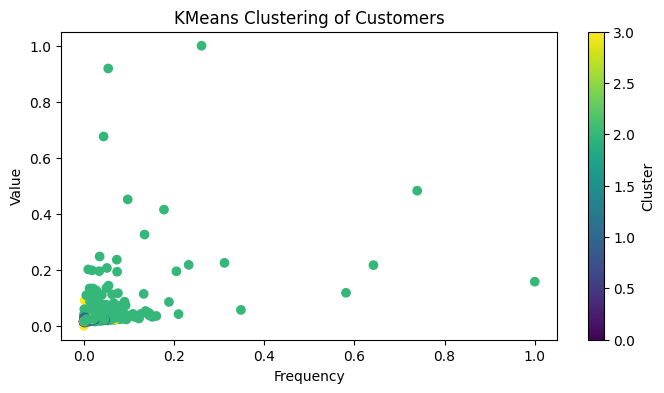

In [62]:
plt.figure(figsize=(8,4))
plt.scatter(rfm_cluster_scaled['Frequency'], rfm_cluster_scaled['Value'], c=pred, cmap='viridis')
plt.xlabel('Frequency')
plt.ylabel('Value')
plt.title('KMeans Clustering of Customers')
plt.colorbar(label='Cluster')
plt.show()

In [70]:
df_rfm = pd.DataFrame(rfm)
df_rfm['cluster'] = pred
df_rfm['cluster'] = df_rfm['cluster'] + 1
df_rfm.head()

,Recency,Frequency,Value,R,F,M,RFM_Segment,RFM_Score,RFM_Segment_Label,RFM_Customer_Segments,cluster
CustomerID,,,,,,,,,,,
12346.0,326,2,0.00,1,1,1,111,3,Low Value,Lost Customers,1
12347.0,2,182,4310.00,4,4,4,444,12,High Value,LoyalCustomers,3
12348.0,75,31,1797.24,2,2,4,224,8,Mid Value,Potential Loyalists,2
12349.0,19,73,1757.55,3,3,4,334,10,High Value,LoyalCustomers,3
12350.0,310,17,334.40,1,1,2,112,4,Low Value,Can't Lose Them,1


In [71]:
df_rfm['cluster'].unique()

array([1, 3, 2, 4], dtype=int32)

In [72]:
df_rfm[['cluster', 'Recency', 'Frequency', 'Value']].groupby('cluster').agg(['mean', 'count'])

Recency         Frequency              Value      
               mean count        mean count         mean count
cluster                                                       
1        309.851779   506   23.217391   506   359.771245   506
2         80.248835  1073   52.956198  1073   980.351726  1073
3         18.524931  2166  146.072484  2166  3092.254077  2166
4        190.451356   627   34.874003   627   587.371341   627

In [73]:
fig = px.scatter_3d(df_rfm, x='Recency', y='Frequency', z='Value', color='cluster',
                    title='Customer Segmentation based on RFM values',
                    labels={'Recency': 'Recency', 'Frequency': 'Frequency', 'Value': 'Value', 'cluster': 'Cluster'})
fig.show()

In [75]:
rfm_df = pd.read_csv(r'C:\Users\Asus\E-commerce customer segmentation & prediction\models\rfm_with_clusters.csv',encoding="cp1252")
# merged_df = pd.merge(df1, rfm_df, on='CustomerID', how='left')
# print(merged_df.head())
rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM_Score,Cluster
0,12346.0,326,2,0.00,1,1,1,3,3
1,12347.0,2,182,4310.00,4,4,4,12,1
2,12348.0,75,31,1797.24,2,2,4,8,4
3,12349.0,19,73,1757.55,3,3,4,10,1
4,12350.0,310,17,334.40,1,1,2,4,3


In [76]:
df_with_clusters = pd.read_csv(r'C:\Users\Asus\E-commerce customer segmentation & prediction\models\rfm_with_clusters.csv',encoding="cp1252")

In [77]:
df_with_clusters.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM_Score,Cluster
0,12346.0,326,2,0.00,1,1,1,3,3
1,12347.0,2,182,4310.00,4,4,4,12,1
2,12348.0,75,31,1797.24,2,2,4,8,4
3,12349.0,19,73,1757.55,3,3,4,10,1
4,12350.0,310,17,334.40,1,1,2,4,3


DBSCAN


In [78]:
rfm_values = rfm[['Recency', 'Frequency', 'Value']]
scaler = StandardScaler()
scaled_rfm = scaler.fit_transform(rfm_values)

In [79]:
dbscan = DBSCAN(eps=0.5, min_samples=5)

In [80]:
df_with_clusters['Clusterdcscan'] = dbscan.fit_predict(scaled_rfm)

In [81]:
# Mark noise points (DBSCAN assigns -1 to noise points)
df_with_clusters['Clusterdcscan'] = df_with_clusters['Clusterdcscan'].apply(lambda x: 'Noise' if x == -1 else f'Cluster {x}')

In [82]:
df_with_clusters['Clusterdcscan'].unique()

array(['Cluster 0', 'Noise', 'Cluster 2', 'Cluster 1'], dtype=object)

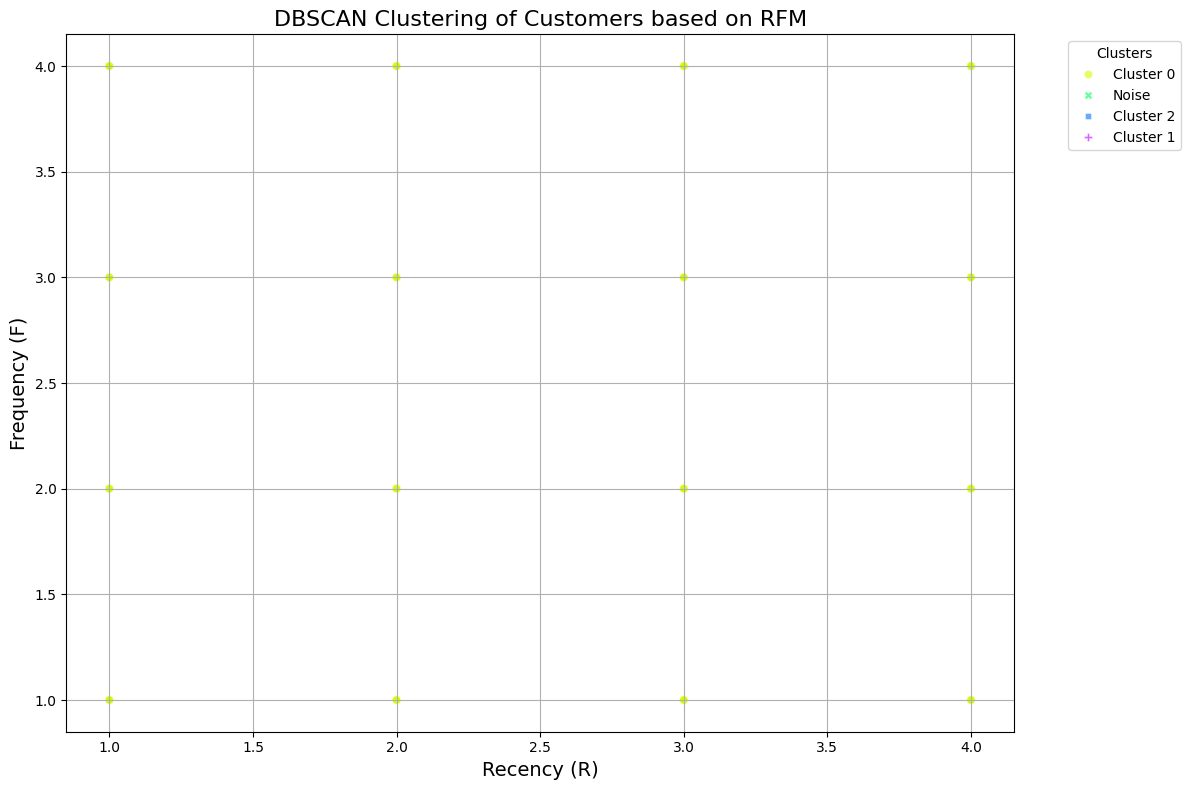

In [83]:
def visualize_clusters():
    plt.figure(figsize=(12, 8))
    palette = sns.color_palette("hsv", len(df_with_clusters['Clusterdcscan'].unique()))

    sns.scatterplot(data=df_with_clusters, x='R', y='M', hue='Clusterdcscan', palette=palette, style='Clusterdcscan', alpha=0.6)
    plt.title('DBSCAN Clustering of Customers based on RFM', fontsize=16)
    plt.xlabel('Recency (R)', fontsize=14)
    plt.ylabel('Frequency (F)', fontsize=14)
    plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid()
    plt.tight_layout()
    plt.show()

visualize_clusters()

In [84]:
df_with_clusters.to_csv('rfm_with_clusters.csv', index=False)

In [85]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'TotalRevenue',
       'InvoiceMonth'],
      dtype='object')

7. Churn Prediction

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

In [94]:
data = pd.read_csv(r'C:\Users\Asus\E-commerce customer segmentation & prediction\models\rfm_with_clusters.csv',encoding="cp1252")
data.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM_Score,Cluster
0,12346.0,326,2,0.00,1,1,1,3,3
1,12347.0,2,182,4310.00,4,4,4,12,1
2,12348.0,75,31,1797.24,2,2,4,8,4
3,12349.0,19,73,1757.55,3,3,4,10,1
4,12350.0,310,17,334.40,1,1,2,4,3


In [95]:
data['Churn'] = data['R'].apply(lambda x: 1 if x > 3 else 0)

In [96]:
data.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM_Score,Cluster,Churn
0,12346.0,326,2,0.00,1,1,1,3,3,0
1,12347.0,2,182,4310.00,4,4,4,12,1,1
2,12348.0,75,31,1797.24,2,2,4,8,4,0
3,12349.0,19,73,1757.55,3,3,4,10,1,0
4,12350.0,310,17,334.40,1,1,2,4,3,0


In [97]:
# Define thresholds
high_risk_threshold = 3  # High-risk threshold
low_risk_threshold = 1   # Low-risk threshold

# Function to assign risk categories
def assign_risk_category(row):
    if row['R'] > high_risk_threshold:
        return 'High Risk'
    elif row['R'] <= low_risk_threshold:
        return 'Low Risk'
    else:
        return 'Medium Risk'

# Apply the function
data['Risk_Category'] = data.apply(assign_risk_category, axis=1)

# Output the DataFrame
print(data)

      CustomerID  Recency  Frequency  Monetary  R  F  M  RFM_Score  Cluster  \
0        12346.0      326          2      0.00  1  1  1          3        3   
1        12347.0        2        182   4310.00  4  4  4         12        1   
2        12348.0       75         31   1797.24  2  2  4          8        4   
3        12349.0       19         73   1757.55  3  3  4         10        1   
4        12350.0      310         17    334.40  1  1  2          4        3   
...          ...      ...        ...       ... .. .. ..        ...      ...   
4367     18280.0      278         10    180.60  1  1  1          3        3   
4368     18281.0      181          7     80.82  1  1  1          3        2   
4369     18282.0        8         13    176.60  4  1  1          6        1   
4370     18283.0        4        756   2094.88  4  4  4         12        1   
4371     18287.0       43         70   1837.28  3  3  4         10        1   

      Churn Risk_Category  
0         0      Low Ri

In [98]:
from sklearn.metrics import classification_report

In [99]:
X = data[['R', 'F', 'M', 'Risk_Category']] # Include 'Risk_Category' as a feature
y = data['Churn']

X = pd.get_dummies(X, columns=['Risk_Category'], prefix='Risk')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       976
           1       1.00      1.00      1.00       336

    accuracy                           1.00      1312
   macro avg       1.00      1.00      1.00      1312
weighted avg       1.00      1.00      1.00      1312



In [108]:
def predict_churn(recency, frequency, monetary):
    try:
        recency = float(recency)
        frequency = float(frequency)
        monetary = float(monetary)
    except ValueError:
        return "Invalid input. Please enter numeric values.", ""

    input_data = pd.DataFrame([[recency, frequency, monetary]], columns=['R', 'F', 'M'])
    # Assuming your model expects these columns: 'R', 'F', 'M', and the Risk Category one-hot encoded
    #  You might need to add the missing Risk columns and handle them appropriately
    #  For a simple example, let's assume all risk is medium for this example.
    input_data['Risk_Category'] = 'Medium Risk'
    input_data = pd.get_dummies(input_data, columns=['Risk_Category'], prefix='Risk')

    # Add missing columns if necessary, with 0s for this prediction
    missing_cols = set(X_train.columns) - set(input_data.columns)
    for c in missing_cols:
        input_data[c] = 0
    input_data = input_data[X_train.columns]  # Ensure same column order


    prediction = clf.predict(input_data)[0]
    churn_status = "Churn / Not a Made a Recent Purchase" if prediction == 0 else "Not Churn / Made a recent Purchase"

    matching_customers = data[(data['R'].round(2) == round(recency, 2)) &
                               (data['F'].round(2) == round(frequency, 2)) &
                               (data['M'].round(2) == round(monetary, 2))]['CustomerID']

    if not matching_customers.empty:
        customer_ids = matching_customers.tolist()
        customer_ids_str = ", ".join(map(str, customer_ids))
    else:
        customer_ids_str = "No matching Customer ID found."

    return churn_status, customer_ids_str